In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from copy import deepcopy
from math import ceil
from sklearn.metrics import confusion_matrix
from time import time
from torch.utils.data import DataLoader, random_split

sns.set_theme()
torch.manual_seed(0)
(current_device := torch.device("cuda" if torch.cuda.is_available() else "cpu"))

device(type='cuda')

# Загрузка, нормализация и разбиение данных

In [2]:
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])
transform_base = transforms.Compose([transforms.ToTensor()])

full_train_aug_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, transform=transform_aug, download=True
)
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, transform=transform_base, download=True
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, transform=transform_base, download=True
)

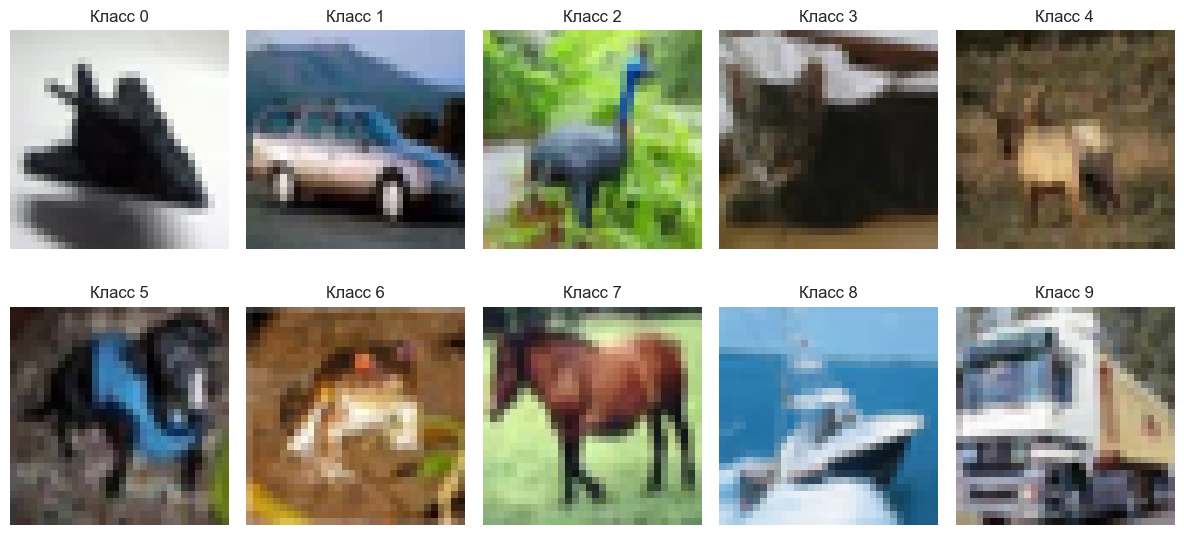

In [3]:
class_indices = {}
for index, (_, label) in enumerate(full_train_dataset):
    if label not in class_indices:
        class_indices[label] = index
    if len(class_indices) == 10:
        break

_, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
axes = axes.flatten()

for label in sorted(class_indices.keys()):
    index = class_indices[label]
    image, _ = full_train_dataset[index]
    axes[label].imshow(image.numpy().transpose(1, 2, 0))
    axes[label].axis("off")
    axes[label].set_title(f"Класс {label}")

plt.tight_layout()

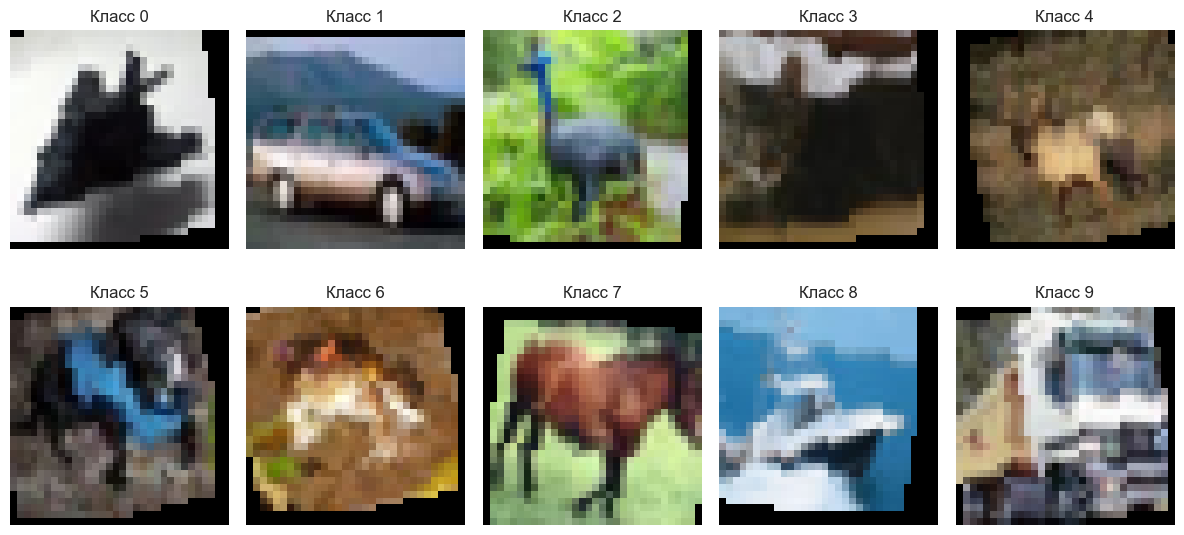

In [4]:
_, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
axes = axes.flatten()

for label in sorted(class_indices.keys()):
    index = class_indices[label]
    image, _ = full_train_aug_dataset[index]
    axes[label].imshow(image.numpy().transpose(1, 2, 0))
    axes[label].axis("off")
    axes[label].set_title(f"Класс {label}")

plt.tight_layout()

In [5]:
print(
    f"Количество изображений для обучения: {len(full_train_dataset)}",
    f"Количество тестовых изображений: {len(test_dataset)}",
    f"Формат одного изображения: {full_train_dataset[0][0].shape}",
    f"Пример истинной метки: {full_train_dataset[0][1]}",
    sep="\n"
)

Количество изображений для обучения: 50000
Количество тестовых изображений: 10000
Формат одного изображения: torch.Size([3, 32, 32])
Пример истинной метки: 6


In [6]:
valid_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - valid_size

train_aug_dataset, valid_aug_dataset = random_split(
    full_train_aug_dataset, [train_size, valid_size]
)
valid_aug_dataset.dataset.transform = transform_base

train_dataset, valid_dataset = random_split(
    full_train_dataset, [train_size, valid_size]
)

print(
    f"Размер обучающей выборки: {len(train_dataset)}",
    f"Размер валидационной выборки: {len(valid_dataset)}",
    sep="\n"
)

Размер обучающей выборки: 40000
Размер валидационной выборки: 10000


In [7]:
batch_size = 256
num_workers = 4

train_aug_loader = DataLoader(train_aug_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valid_aug_loader = DataLoader(valid_aug_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

batch_images, batch_labels = next(iter(test_loader))

print(
    f"Форма батча изображений: {batch_images.shape}",
    f"Форма батча меток: {batch_labels.shape}",
    sep="\n"
)

Форма батча изображений: torch.Size([256, 3, 32, 32])
Форма батча меток: torch.Size([256])


# Создание моделей

In [ ]:
class CNN1(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (batch, 3, 32, 32) -> (batch, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 32, 32, 32) -> (batch, 32, 16, 16)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (batch, 32, 16, 16) -> (batch, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 64, 16, 16) -> (batch, 64, 8, 8)
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (batch, 64, 8, 8) -> (batch, 128, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 128, 8, 8) -> (batch, 128, 4, 4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # (batch, 128, 4, 4) -> (batch, 4096)
            nn.Linear(128 * 4 * 4, 256),  # (batch, 4096) -> (batch, 256)
            nn.ReLU(),
            nn.Linear(256, n_classes),  # (batch, 256) -> (batch, n_classes)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)
        return x


class CNN2(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (batch, 3, 32, 32) -> (batch, 32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 32, 32, 32) -> (batch, 32, 16, 16)
            nn.Dropout2d(0.1),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (batch, 32, 16, 16) -> (batch, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 64, 16, 16) -> (batch, 64, 8, 8)
            nn.Dropout2d(0.1),
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (batch, 64, 8, 8) -> (batch, 128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 128, 8, 8) -> (batch, 128, 4, 4)
            nn.Dropout2d(0.1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # (batch, 128, 4, 4) -> (batch, 4096)
            nn.Linear(128 * 4 * 4, 256),  # (batch, 4096) -> (batch, 256)
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),  # (batch, 256) -> (batch, n_classes)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)
        return x


class CNN3(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (batch, 3, 32, 32) -> (batch, 32, 32, 32)
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  # (batch, 32, 32, 32) -> (batch, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 32, 32, 32) -> (batch, 32, 16, 16)
            nn.Dropout2d(0.2),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (batch, 32, 16, 16) -> (batch, 64, 16, 16)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # (batch, 64, 16, 16) -> (batch, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 64, 16, 16) -> (batch, 64, 8, 8)
            nn.Dropout2d(0.3),
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (batch, 64, 8, 8) -> (batch, 128, 8, 8)
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),  # (batch, 128, 8, 8) -> (batch, 128, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2),  # (batch, 128, 8, 8) -> (batch, 128, 4, 4)
            nn.Dropout2d(0.4),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),  # (batch, 128, 4, 4) -> (batch, 4096)
            nn.Linear(128 * 4 * 4, 256),  # (batch, 4096) -> (batch, 256)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),  # (batch, 256) -> (batch, n_classes)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)
        return x


class EarlyStopping:
    def __init__(self, patience, min_delta, mode):
        self.patience = patience  # количество эпох без улучшений, после которых нужна остановка
        self.min_delta = min_delta  # минимальное изменение, считающееся улучшением
        self.mode = mode  # "max" – чем больше, тем лучше; "min" – чем меньше, тем лучше
        self.counter = 0  # счётчик эпох без улучшений
        self.best_score = None  # лучшее значение метрики оценки качества
        self.early_stop = False  # флаг необходимости остановки
        self.best_model_state = None  # состояние лучшей модели
    
    def __call__(self, current_score, model):
        # Первый вызов
        if self.best_score is None:
            # Сохранение значения метрики
            self.best_score = current_score
            # Сохранение весов модели
            self.best_model_state = deepcopy(model.state_dict())

        # Проверка на отсутствие улучшения
        elif (self.mode == "max" and current_score < self.best_score + self.min_delta) or \
             (self.mode == "min" and current_score > self.best_score - self.min_delta):
            # Увеличение счётчика эпох без улучшений
            self.counter += 1
            # Если достигнуто задананное количество эпох без улучшений, то выполняется остановка
            if self.counter >= self.patience:
                self.early_stop = True
        
        # Фиксация улучшения
        else:
            # Сохранение лушчего значения метрики
            self.best_score = current_score
            # Сохранение лучших весов модели
            self.best_model_state = deepcopy(model.state_dict())
            # Обнуление счётчика эпоха без улучшений
            self.counter = 0


def train_epoch(model, loader, optimizer, criterion, device):
    # Переключение модели в режим обучения
    model.train()

    running_loss = 0.0  # суммарная ошибка
    correct = 0  # количество правильных ответов
    total = 0  # общее число обработанных примеров

    # Проход по батчам данных
    for inputs, targets in loader:
        # Перемещение тензоров на указанный CPU или GPU
        inputs, targets = inputs.to(device), targets.to(device)

        # Обнуление градиентов перед вычислением градиентов нового батча
        optimizer.zero_grad()
        # Прямой проход: получение сырых предсказаний
        outputs = model(inputs)
        # Вычисление функции потерь
        loss = criterion(outputs, targets)
        # Обратный проход: вычисление градиентов функции потерь по всем параметрам модели
        loss.backward()
        # Обновление весов модели
        optimizer.step()
        
        # Прибавление суммарных потерь для всех примеров батча
        running_loss += loss.item() * inputs.size(0)
        # Получение предсказанных классов
        _, predicted = torch.max(outputs, 1)
        # Прибавление количества обработанных примеров
        total += targets.size(0)
        # Прибавление количества верных ответов
        correct += (predicted == targets).sum().item()
    
    # Вычисление средних потерь за эпоху
    epoch_loss = running_loss / total
    # Вычисление точности за эпоху
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    # Переключение модели в режим оценки
    model.eval()

    running_loss = 0.0  # суммарная ошибка
    correct = 0  # количество правильных ответов
    total = 0  # общее число обработанных примеров

    # Отключение автоматического вычисления градиентов
    with torch.no_grad():
        # Проход по батчам данных
        for inputs, targets in loader:
            # Перемещение тензоров на указанный CPU или GPU
            inputs, targets = inputs.to(device), targets.to(device)

            # Прямой проход: получение сырых предсказаний
            outputs = model(inputs)
            # Вычисление функции потерь
            loss = criterion(outputs, targets)

            # Прибавление суммарных потерь для всех примеров батча
            running_loss += loss.item() * inputs.size(0)
            # Получение предсказанных классов
            _, predicted = torch.max(outputs, 1)
            # Прибавление количества обработанных примеров
            total += targets.size(0)
            # Прибавление количества верных ответов
            correct += (predicted == targets).sum().item()
    
    # Вычисление средних потерь за эпоху
    epoch_loss = running_loss / total
    # Вычисление точности за эпоху
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def predict(model, loader, device):
    # Переключение модели в режим оценки
    model.eval()

    # Список для тензоров вероятностей
    all_probs = []

    # Отключение автоматического вычисления градиентов
    with torch.no_grad():
        # Проход по батчам данных
        for data, _ in loader:
            # Перемещение тензоров на указанный CPU или GPU
            data = data.to(device)
            
            # Прямой проход: получение сырых предсказаний (логитов)
            output = model(data)

            # Преобразование логитов в вероятности распределения по классам
            probs = torch.softmax(output, dim=1)

            # Перемещение тензоров с GPU на CPU при необходимости
            # и добавление в список тензора вида (batch_size, 10)
            all_probs.append(probs.cpu())
    
    # Объединение списка тензоров в один массив вида (loader_size, 10)
    return torch.cat(all_probs).numpy()

In [ ]:
models = {
    "CNN_3_Conv": CNN1(n_classes=10),
    "CNN_3_Conv_Norm_Drop": CNN2(n_classes=10),
    "CNN_6_Conv_Drop": CNN3(n_classes=10),

    "CNN_3_Conv_Aug": CNN1(n_classes=10),
    "CNN_3_Conv_Norm_Drop_Aug": CNN2(n_classes=10),
    "CNN_6_Conv_Drop_Aug": CNN3(n_classes=10),
}

for model in models.values():
    model = model.to(current_device)

models_info = {
    "CNN_3_Conv": (3, 3, 0, 0, 0, 0, 1, 2, 4),
    "CNN_3_Conv_Norm_Drop": (3, 3, 3, 1, 3, 1, 1, 2, 4),
    "CNN_6_Conv_Drop": (6, 3, 0, 0, 3, 1, 1, 2, 7),
}

models_list = []

for _, model_name in zip(range(3), models.keys()):
    model = models[model_name]

    models_list.append({
        "Модель": model_name,
        "Параметров": sum(p.numel() for p in model.parameters()),
        "Conv2d": models_info[model_name][0],
        "MaxPool2d": models_info[model_name][1],
        "BatchNorm2d": models_info[model_name][2],
        "BatchNorm1d": models_info[model_name][3],
        "Dropout2d": models_info[model_name][4],
        "Dropout": models_info[model_name][5],
        "Flatten": models_info[model_name][6],
        "Linear": models_info[model_name][7],
        "ReLU": models_info[model_name][8],
    })

models_df = pd.DataFrame(models_list)
models_df.style.hide(axis="index")

Модель,Параметров,Conv2d,MaxPool2d,BatchNorm2d,BatchNorm1d,Dropout2d,Dropout,Flatten,Linear,ReLU
CNN_3_Conv,620362,3,3,0,0,0,0,1,2,4
CNN_3_Conv_Norm_Drop,621322,3,3,3,1,3,1,1,2,4
CNN_6_Conv_Drop,814122,6,3,0,0,3,1,1,2,7


# Обучение моделей

In [ ]:
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
n_epochs = 50

early_stopping_patience = 5
early_stopping_min_delta = 0.001
early_stopping_mode = "max"

histories = {}

for model_name, model in models.items():
    model = model.to(current_device)
    
    print(f"Обучение модели '{model_name}':")
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    early_stopping = EarlyStopping(
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
        mode=early_stopping_mode,
    )
    
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    start_time = time()
    
    for epoch in range(n_epochs):
        epoch_start_time = time()

        if model_name.endswith("Aug"):
            train_loss, train_acc = train_epoch(model, train_aug_loader, optimizer, criterion, current_device)
            valid_loss, valid_acc = evaluate(model, valid_aug_loader, criterion, current_device)
        else:
            train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, current_device)
            valid_loss, valid_acc = evaluate(model, valid_loader, criterion, current_device)

        epoch_end_time = time()
        epoch_time = round(epoch_end_time - epoch_start_time)
        
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)
        
        print(f"Epoch {epoch + 1:2d}/{n_epochs} ({epoch_time}s) - "
              f"train_acc: {train_acc:.4f} - train_loss: {train_loss:.4f} - "
              f"valid_acc: {valid_acc:.4f} - valid_loss: {valid_loss:.4f}")
        
        early_stopping(valid_acc, model)
        if early_stopping.early_stop:
            print(f"Ранняя остановка на эпохе {epoch + 1}")
            break
    
    end_time = time()
    elapsed_time = round(end_time - start_time)

    model.load_state_dict(early_stopping.best_model_state)
    best_epoch = len(train_losses) - early_stopping.counter
    print(f"Лучшая точность на валидации: {early_stopping.best_score:.4f} (эпоха {best_epoch})")

    print(f"Время обучения модели '{model_name}': {elapsed_time} секунд\n")
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, current_device)

    torch.save(model.state_dict(), f"./models/{model_name}.pt")
    
    histories[model_name] = {
        "train_losses": train_losses,
        "train_accs": train_accs,
        "valid_losses": valid_losses,
        "valid_accs": valid_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "best_epoch": best_epoch,
    }

Обучение модели 'CNN_3_Conv':
Epoch  1/50 (36s) - train_acc: 0.3522 - train_loss: 1.7814 - valid_acc: 0.4113 - valid_loss: 1.5937
Epoch  2/50 (36s) - train_acc: 0.4974 - train_loss: 1.3901 - valid_acc: 0.5363 - valid_loss: 1.2934
Epoch  3/50 (37s) - train_acc: 0.5575 - train_loss: 1.2487 - valid_acc: 0.5734 - valid_loss: 1.1992
Epoch  4/50 (36s) - train_acc: 0.5991 - train_loss: 1.1360 - valid_acc: 0.5884 - valid_loss: 1.1652
Epoch  5/50 (36s) - train_acc: 0.6312 - train_loss: 1.0431 - valid_acc: 0.6370 - valid_loss: 1.0312
Epoch  6/50 (36s) - train_acc: 0.6628 - train_loss: 0.9636 - valid_acc: 0.6306 - valid_loss: 1.0543
Epoch  7/50 (37s) - train_acc: 0.6852 - train_loss: 0.8971 - valid_acc: 0.6765 - valid_loss: 0.9288
Epoch  8/50 (36s) - train_acc: 0.7100 - train_loss: 0.8328 - valid_acc: 0.6785 - valid_loss: 0.9143
Epoch  9/50 (37s) - train_acc: 0.7231 - train_loss: 0.7901 - valid_acc: 0.6970 - valid_loss: 0.8741
Epoch 10/50 (37s) - train_acc: 0.7438 - train_loss: 0.7319 - valid_acc

In [13]:
results_list = []

for model_name, history in histories.items():
    best_epoch = history["best_epoch"]

    results_list.append({
        "model": model_name,
        "stop_epoch": min(n_epochs, best_epoch + early_stopping_patience),
        "best_epoch": best_epoch,
        "train_loss": f"{history["train_losses"][best_epoch - 1]:.4f}",
        "train_acc": f"{history["train_accs"][best_epoch - 1]:.4f}",
        "valid_loss": f"{history["valid_losses"][best_epoch - 1]:.4f}",
        "valid_acc": f"{history["valid_accs"][best_epoch - 1]:.4f}",
        "test_loss": f"{history["test_loss"]:.4f}",
        "test_acc": f"{history["test_acc"]:.4f}",
    })

results_df = pd.DataFrame(results_list)
results_df.style.hide(axis="index")

model,stop_epoch,best_epoch,train_loss,train_acc,valid_loss,valid_acc,test_loss,test_acc
CNN_3_Conv,21,16,0.4783,0.8336,0.8334,0.7302,0.8480,0.7234
CNN_3_Conv_Norm_Drop,25,20,0.3859,0.8620,0.6701,0.7845,0.6678,0.7856
CNN_6_Conv_Drop,50,49,0.5524,0.8048,0.5982,0.7965,0.6281,0.7953
CNN_3_Conv_Aug,20,15,0.4180,0.8557,0.8801,0.7272,0.8973,0.7209
CNN_3_Conv_Norm_Drop_Aug,28,23,0.3554,0.8724,0.6408,0.7948,0.6812,0.7821
CNN_6_Conv_Drop_Aug,50,48,0.5337,0.8087,0.6040,0.7987,0.6399,0.7916


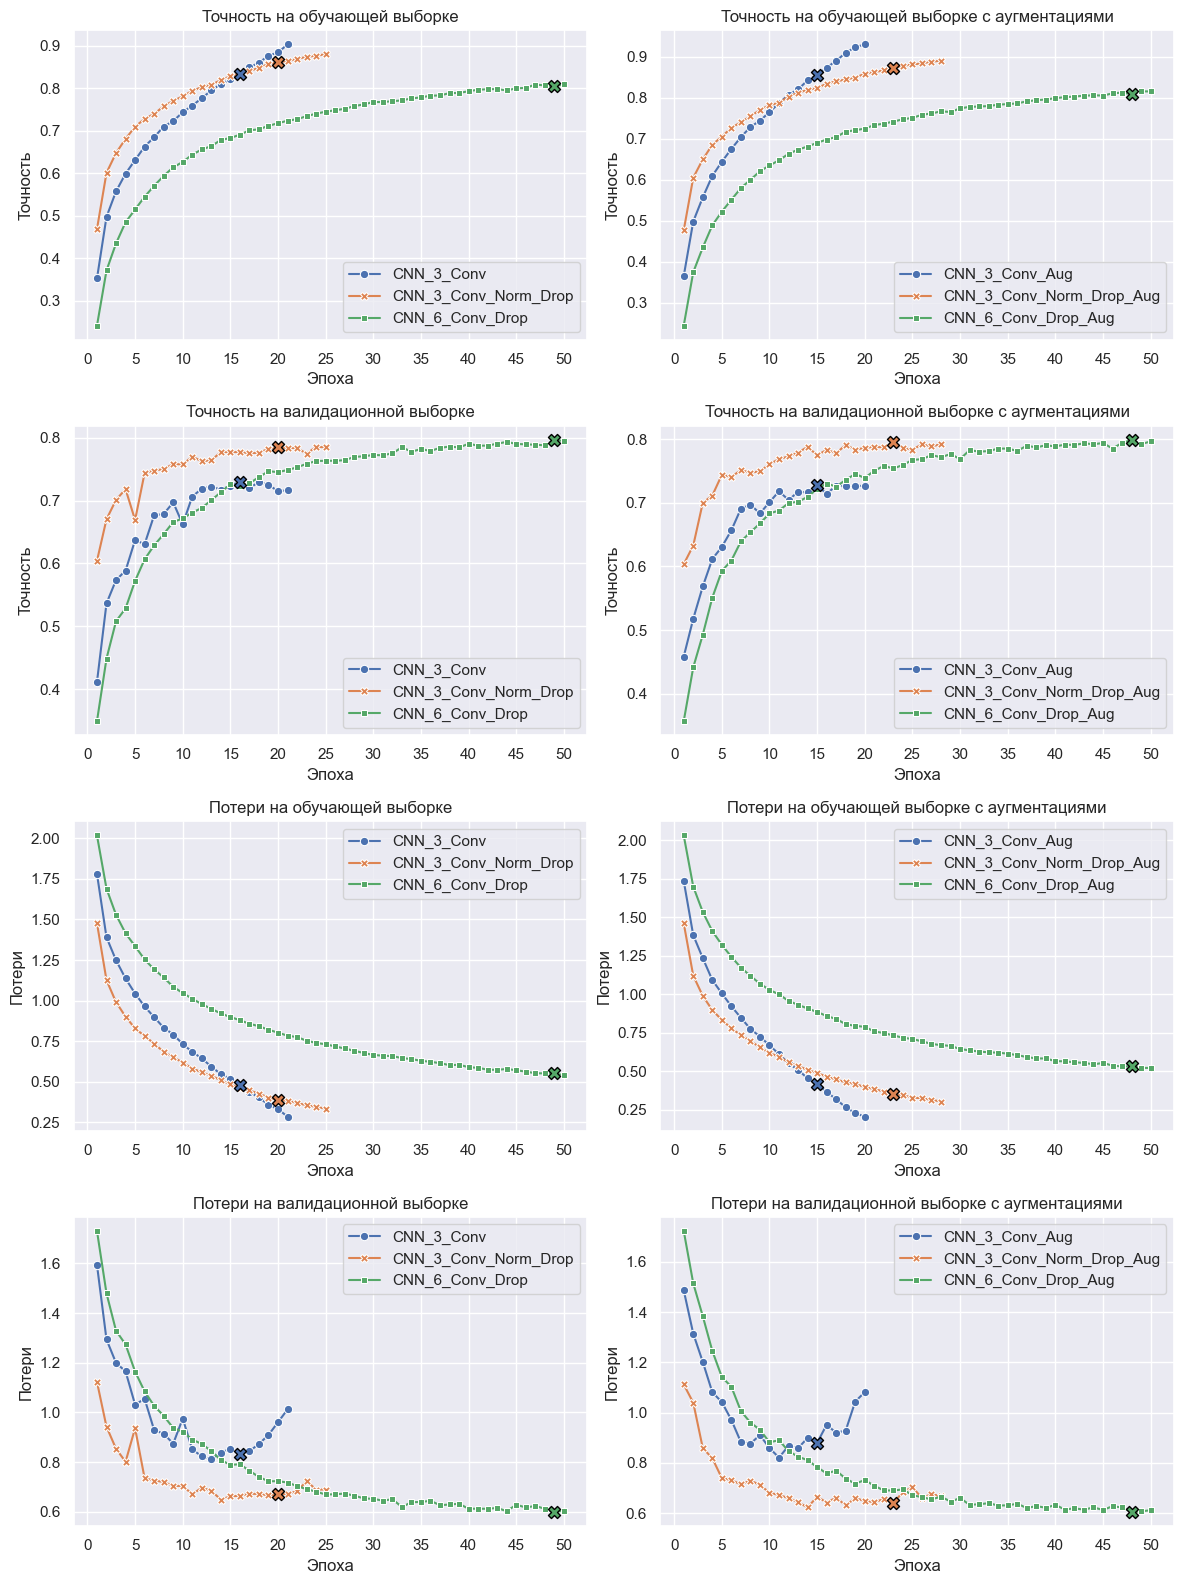

In [ ]:
records_list, records_aug_list = [], []
best_epochs, best_epochs_aug = [], []

for model_name, history in histories.items():
    best_epoch = history["best_epoch"]

    best_epoch_metrics = {
        "model": model_name,
        "best_epoch": best_epoch,
        "train_acc": history["train_accs"][best_epoch - 1],
        "valid_acc": history["valid_accs"][best_epoch - 1],
        "train_loss": history["train_losses"][best_epoch - 1],
        "valid_loss": history["valid_losses"][best_epoch - 1],
    }

    if model_name.endswith("Aug"):
        current_records_list = records_aug_list
        best_epochs_aug.append(best_epoch_metrics)
    else:
        current_records_list = records_list
        best_epochs.append(best_epoch_metrics)

    for epoch, (train_acc, valid_acc, train_loss, valid_loss) in enumerate(zip(
        history["train_accs"], history["valid_accs"], history["train_losses"], history["valid_losses"]
    )):
        current_records_list.append({
            "model": model_name,
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "valid_acc": valid_acc,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
        })
    
records_df = pd.DataFrame(records_list)
records_aug_df = pd.DataFrame(records_aug_list)

plot_params = {
    "y": ["train_acc", "valid_acc", "train_loss", "valid_loss"],
    "title": [
        "Точность на обучающей выборке",
        "Точность на обучающей выборке с аугментациями",
        "Точность на валидационной выборке",
        "Точность на валидационной выборке с аугментациями",
        "Потери на обучающей выборке",
        "Потери на обучающей выборке с аугментациями",
        "Потери на валидационной выборке",
        "Потери на валидационной выборке с аугментациями",
    ],
    "ylabel": ["Точность", "Потери"],
}

n_rows, n_cols = 4, 2
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 16))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i % 2 == 0:
        df = records_df
        epochs = best_epochs
    else:
        df = records_aug_df
        epochs = best_epochs_aug

    metric = plot_params["y"][i // 2]

    sns.lineplot(
        data=df, x="epoch", y=metric, hue="model", style="model", dashes=False, markers=True, ax=ax,
    ).set(
        title=plot_params["title"][i], xlabel="Эпоха", xticks=range(0, 51, 5),
        ylabel=plot_params["ylabel"][i // 4],
    )

    for epoch, color in zip(epochs, sns.color_palette(n_colors=len(epochs))):
        ax.scatter(
            x=epoch["best_epoch"], y=epoch[metric], s=75,
            color=color, marker="X", edgecolor="black", zorder=5
        )

    ax.legend(title="", loc="lower right" if i < 4 else "upper right")

plt.tight_layout()

# Тестирование и оценка качества моделей

In [15]:
for model_name, model in models.items():
    model.load_state_dict(torch.load(f"./models/{model_name}.pt"))

In [24]:
y_true = np.array(test_dataset.targets)

preds = []

for model_name, model in models.items():
    y_pred_proba = predict(model, test_loader, current_device)

    y_pred = np.argmax(y_pred_proba, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    preds.append((model_name, y_pred_proba, y_pred, cm))

preds[0]

('CNN_3_Conv',
 array([[1.06892188e-03, 3.18583974e-04, 4.48048697e-04, ...,
         4.60575575e-05, 5.20342449e-03, 6.93136535e-04],
        [1.65729038e-03, 1.05402134e-01, 6.33350936e-08, ...,
         3.54018653e-07, 8.92842412e-01, 9.69081448e-05],
        [1.62587017e-01, 4.26327204e-03, 2.21515264e-04, ...,
         2.20076996e-03, 8.28526437e-01, 1.01932546e-03],
        ...,
        [2.35492444e-05, 8.21414119e-07, 1.16659254e-02, ...,
         2.35696137e-03, 4.43014942e-05, 6.02226828e-05],
        [1.85476970e-02, 3.51901539e-02, 8.54543119e-04, ...,
         3.20414733e-03, 1.13731076e-04, 7.84535496e-06],
        [3.51583850e-07, 7.92650326e-07, 2.22152848e-05, ...,
         9.60881412e-01, 4.66516852e-08, 8.59177618e-08]],
       shape=(10000, 10), dtype=float32),
 array([3, 8, 8, ..., 5, 4, 7], shape=(10000,)),
 array([[849,  10,  27,   6,  17,   6,  13,   6,  37,  29],
        [ 31, 810,   9,   8,   2,   2,   8,   0,  23, 107],
        [ 81,   7, 575,  58,  88,  52,  

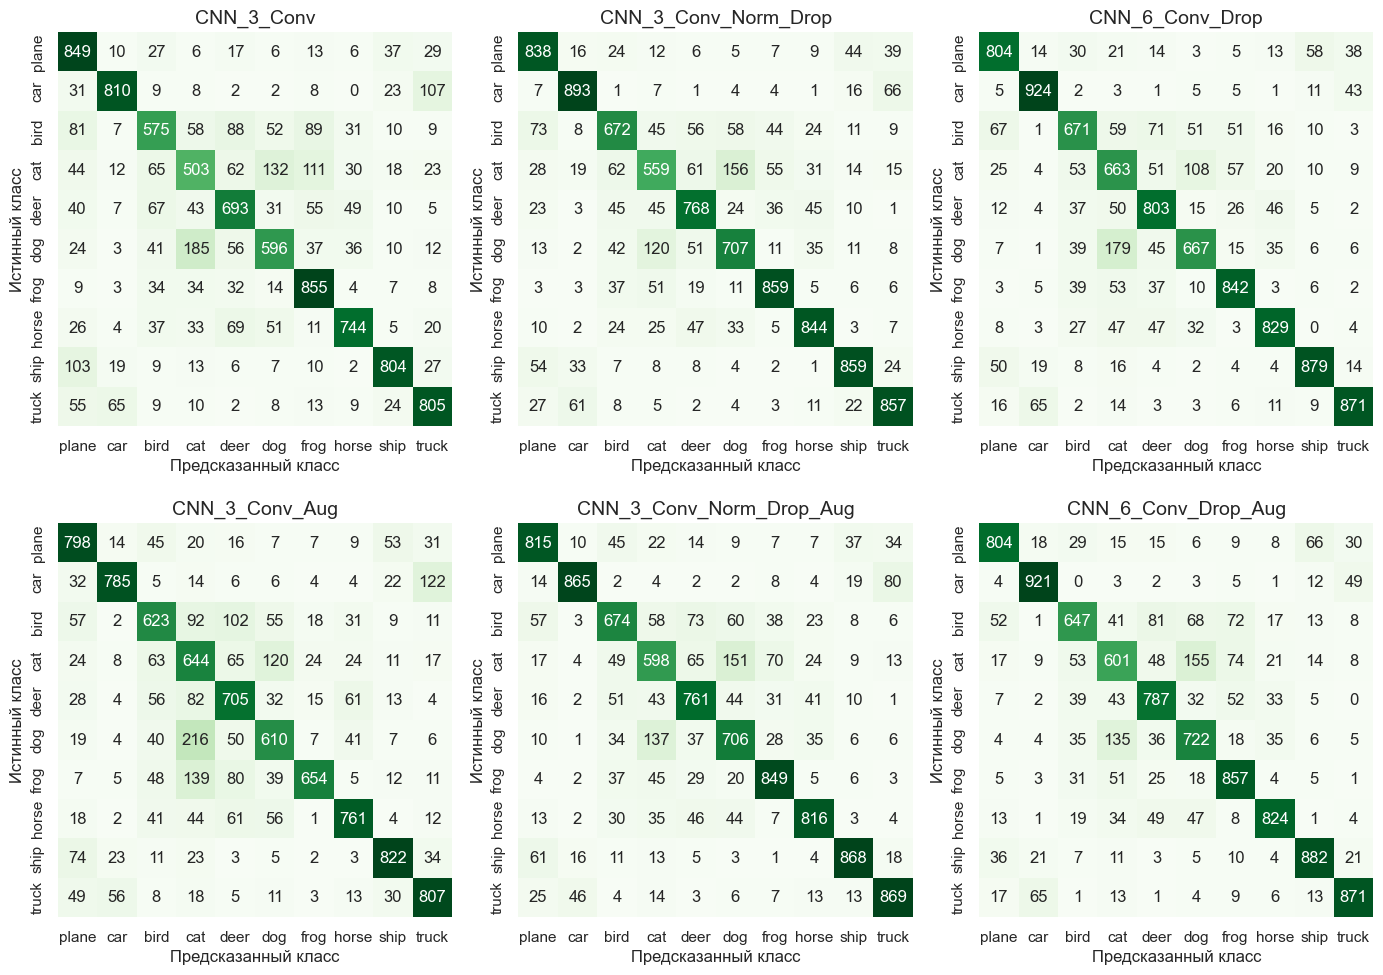

In [27]:
class_names = np.array([
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
])

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 10))
axes = axes.flatten()

for i, (model_name, _, _, cm) in enumerate(preds):
    sns.heatmap(
        cm, cmap="Greens", annot=True, fmt="d", cbar=False, square=True, ax=axes[i]
    ).set(
        xlabel="Предсказанный класс", ylabel="Истинный класс",
        xticklabels=class_names, yticklabels=class_names
    )
    axes[i].set_title(model_name, fontsize=14)

plt.tight_layout()

In [30]:
error_masks = []
errors = []

for i, (model_name, _, model_preds, _) in enumerate(preds):
    mask = (model_preds != y_true)
    error_masks.append(mask)

    n_errors = np.sum(mask)
    n_errors_by_class = np.bincount(y_true[mask], minlength=10)

    errors.append([model_name] + n_errors_by_class.tolist() + [n_errors])

errors_df = pd.DataFrame(
    errors, columns=["Модель"] + class_names.tolist() + ["Всего"]
)
errors_df.style.hide(axis="index")

Модель,plane,car,bird,cat,deer,dog,frog,horse,ship,truck,Всего
CNN_3_Conv,151,190,425,497,307,404,145,256,196,195,2766
CNN_3_Conv_Norm_Drop,162,107,328,441,232,293,141,156,141,143,2144
CNN_6_Conv_Drop,196,76,329,337,197,333,158,171,121,129,2047
CNN_3_Conv_Aug,202,215,377,356,295,390,346,239,178,193,2791
CNN_3_Conv_Norm_Drop_Aug,185,135,326,402,239,294,151,184,132,131,2179
CNN_6_Conv_Drop_Aug,196,79,353,399,213,278,143,176,118,129,2084


In [31]:
error_indices = np.where(np.logical_and.reduce(error_masks))[0]
len(error_indices)

692

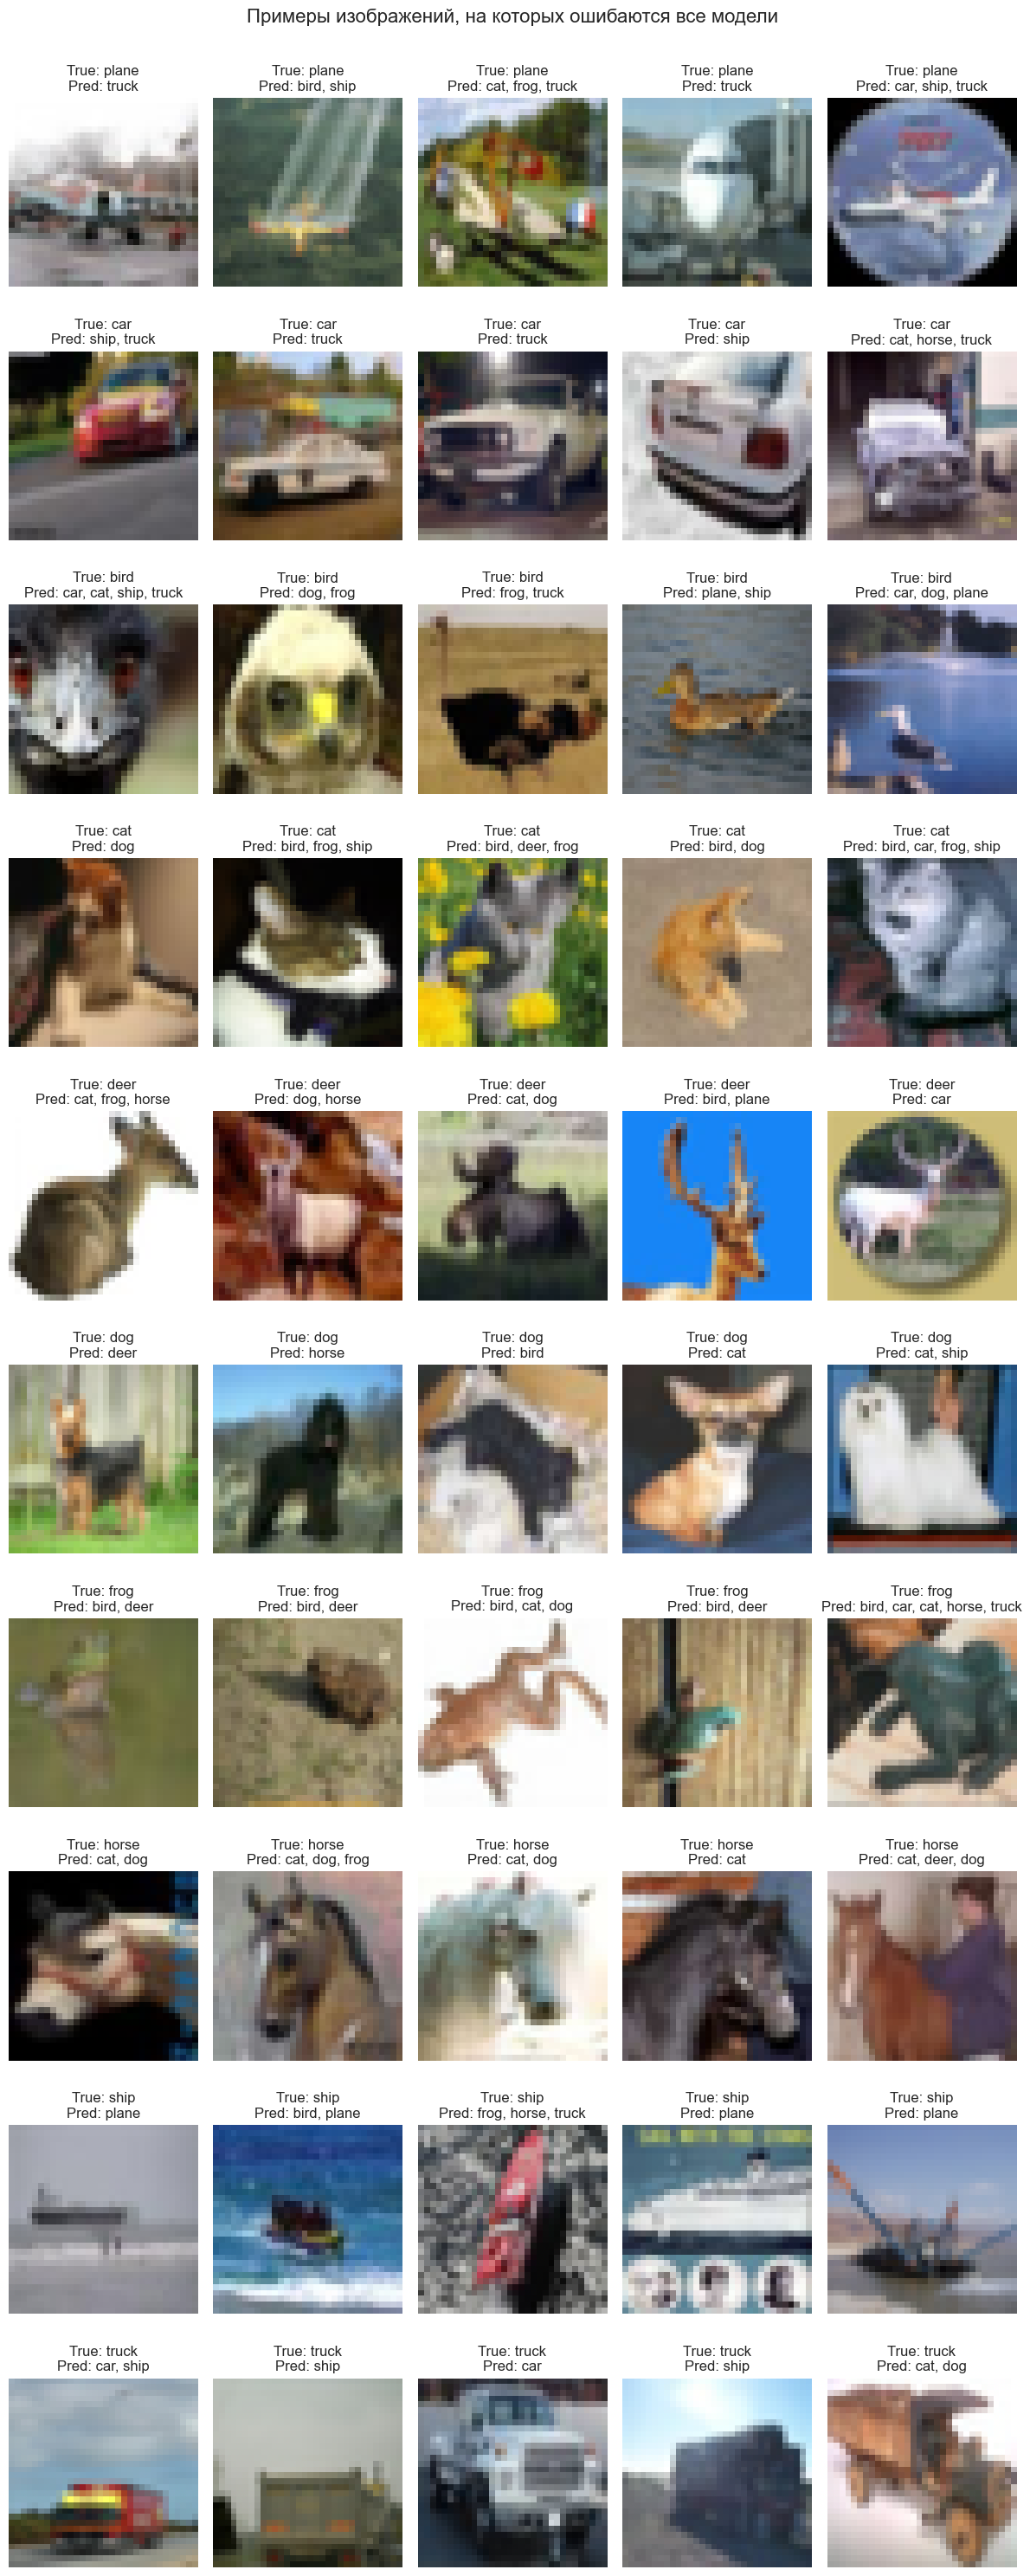

In [48]:
error_indices_by_class = {i: [] for i in range(10)}
for error_index in error_indices:
    _, label = test_dataset[error_index]
    if len(error_indices_by_class[label]) < 5:
        error_indices_by_class[label].append(error_index)
    if all(len(error_indices_by_class[i]) == 5 for i in range(10)):
        break

n_cols = 5
n_rows = ceil(min(50, len(error_indices)) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 3))

fig.suptitle(f"Примеры изображений, на которых ошибаются все модели", fontsize=16, y=1)

for label in range(10):
    for i, error_index in enumerate(error_indices_by_class[label]):
        image, _ = test_dataset[error_index]
        axes[label, i].imshow(image.numpy().transpose(1, 2, 0))
        axes[label, i].axis("off")

        all_preds = [class_names[preds[i][2][error_index]] for i in range(len(preds))]
        all_preds_str = ", ".join(map(str, sorted(set(all_preds))))
        axes[label, i].set_title(f"True: {class_names[y_true[error_index]]}\nPred: {all_preds_str}")

plt.tight_layout()

Всего 137 изображений, где класс 'plane' принят за 'ship'


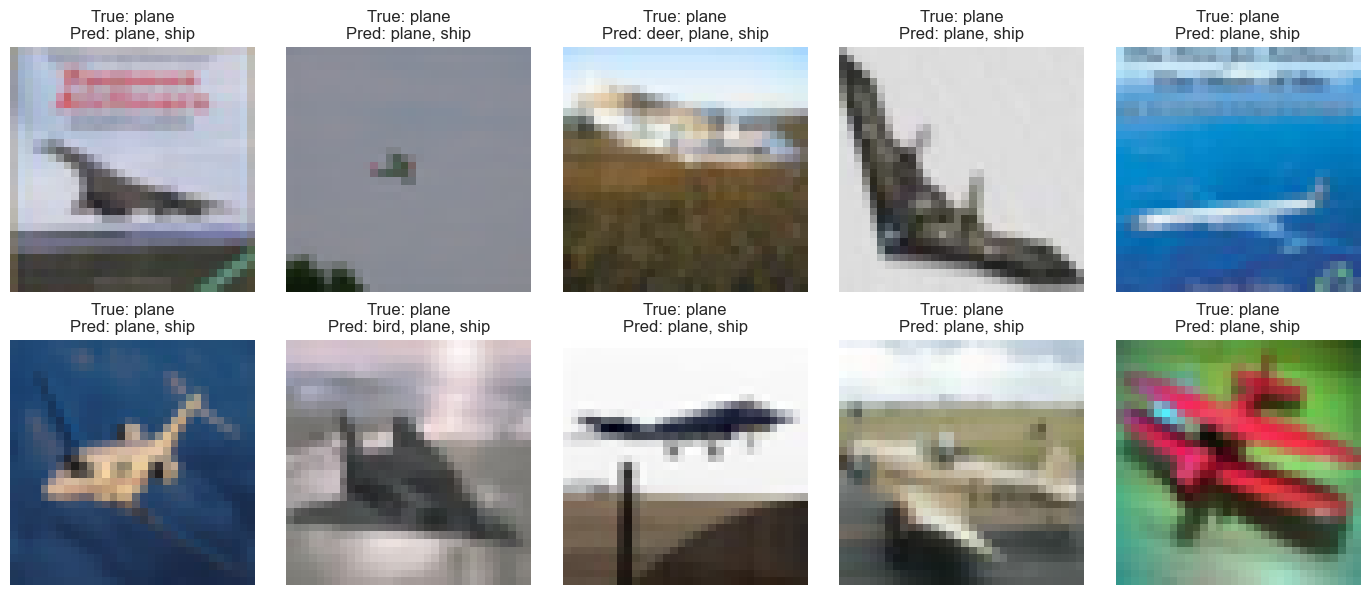

In [81]:
y_true_names = class_names[y_true]
y_pred_names = [class_names[model_preds[2]] for model_preds in preds]

def get_error_indices(true, pred):
    error_indices = []

    for i in np.where(y_true_names == true)[0]:
        for y_pred_name in y_pred_names:
            if y_pred_name[i] == pred:
                error_indices.append(i)
                break

    print(f"Всего {len(error_indices)} изображений, где класс '{true}' принят за '{pred}'")
    
    return error_indices


def plot_errors(error_indices, n_samples):
    n_cols = 5
    n_rows = ceil(len(error_indices[:n_samples]) / n_cols)

    _, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, n_rows * 3))
    axes = axes.flatten()

    for ax, error_index in zip(axes, error_indices[:n_samples]):
        image, _ = test_dataset[error_index]
        ax.imshow(image.numpy().transpose(1, 2, 0))
        ax.axis("off")

        all_preds = [class_names[preds[i][2][error_index]] for i in range(len(preds))]
        all_preds_str = ", ".join(map(str, sorted(set(all_preds))))
        ax.set_title(f"True: {class_names[y_true[error_index]]}\nPred: {all_preds_str}")

    for ax in axes[len(error_indices[:n_samples]):]:
        ax.axis("off")

    plt.tight_layout(h_pad=2)


plot_errors(get_error_indices(true="plane", pred="ship"), n_samples=10)

Всего 173 изображений, где класс 'ship' принят за 'plane'


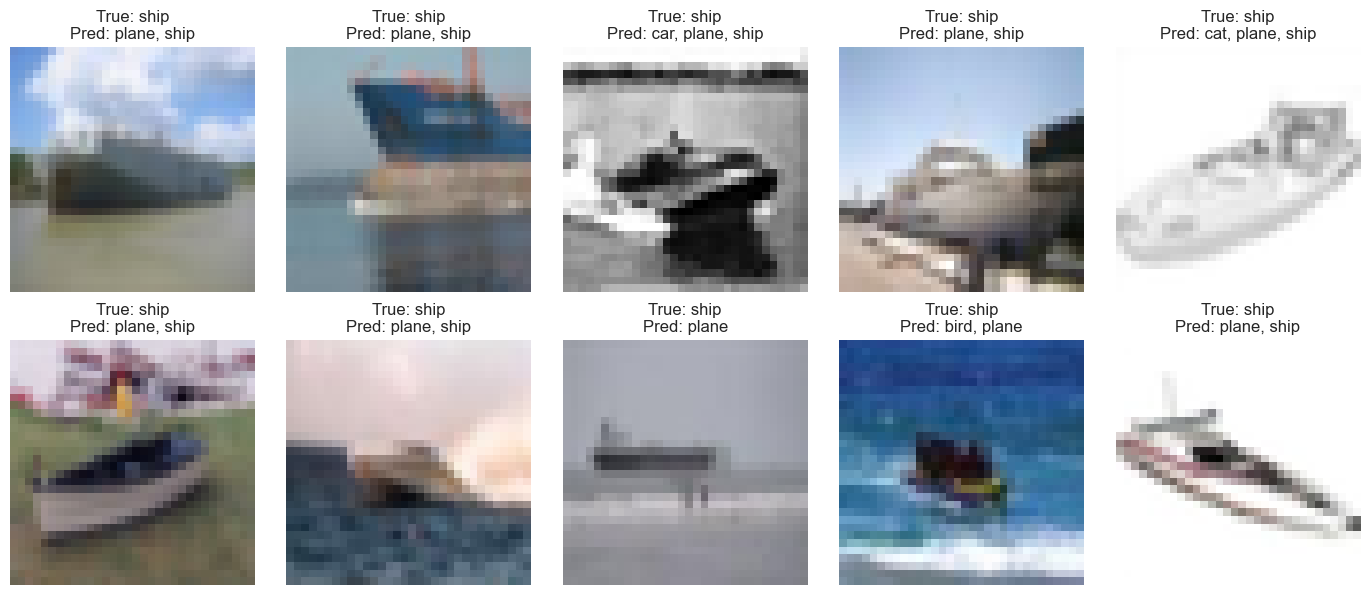

In [82]:
plot_errors(get_error_indices(true="ship", pred="plane"), n_samples=10)

Всего 223 изображений, где класс 'car' принят за 'truck'


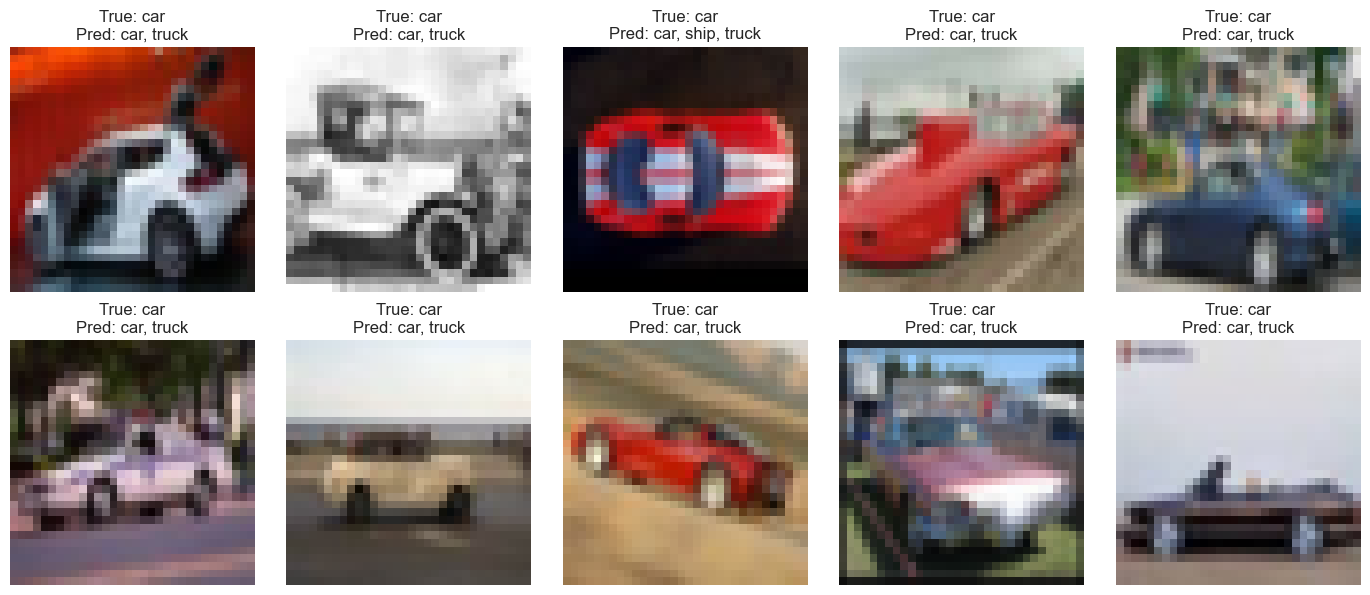

In [83]:
plot_errors(get_error_indices(true="car", pred="truck"), n_samples=10)

Всего 172 изображений, где класс 'truck' принят за 'car'


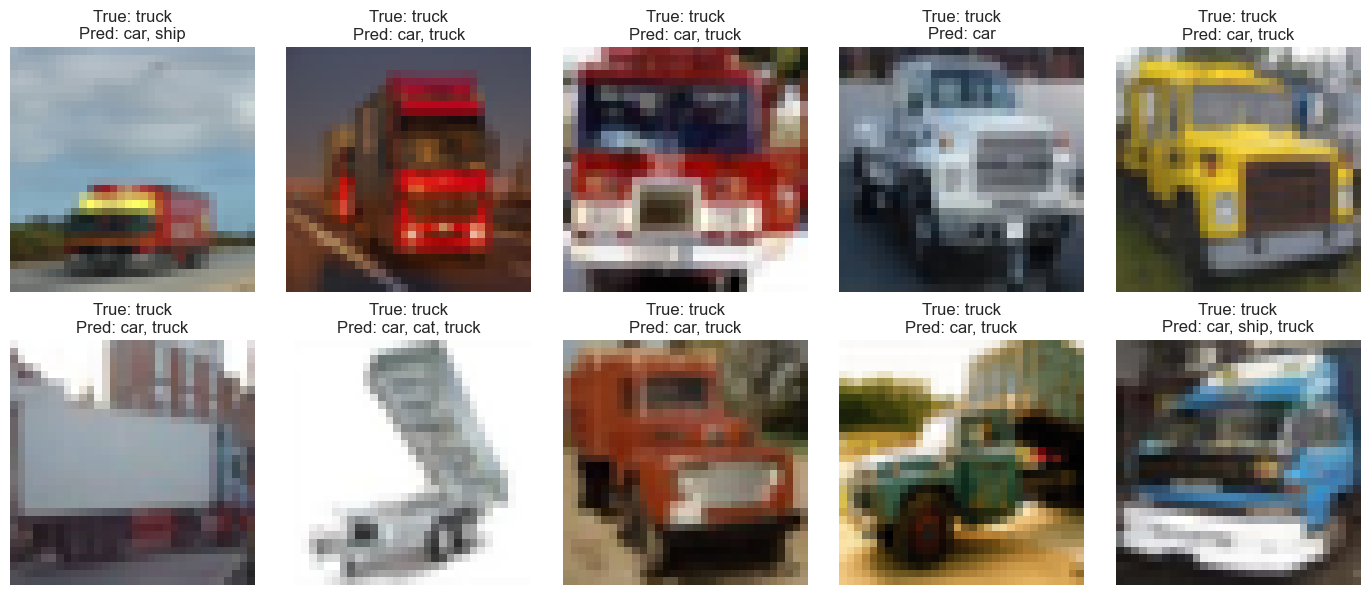

In [84]:
plot_errors(get_error_indices(true="truck", pred="car"), n_samples=10)

Всего 351 изображений, где класс 'cat' принят за 'dog'


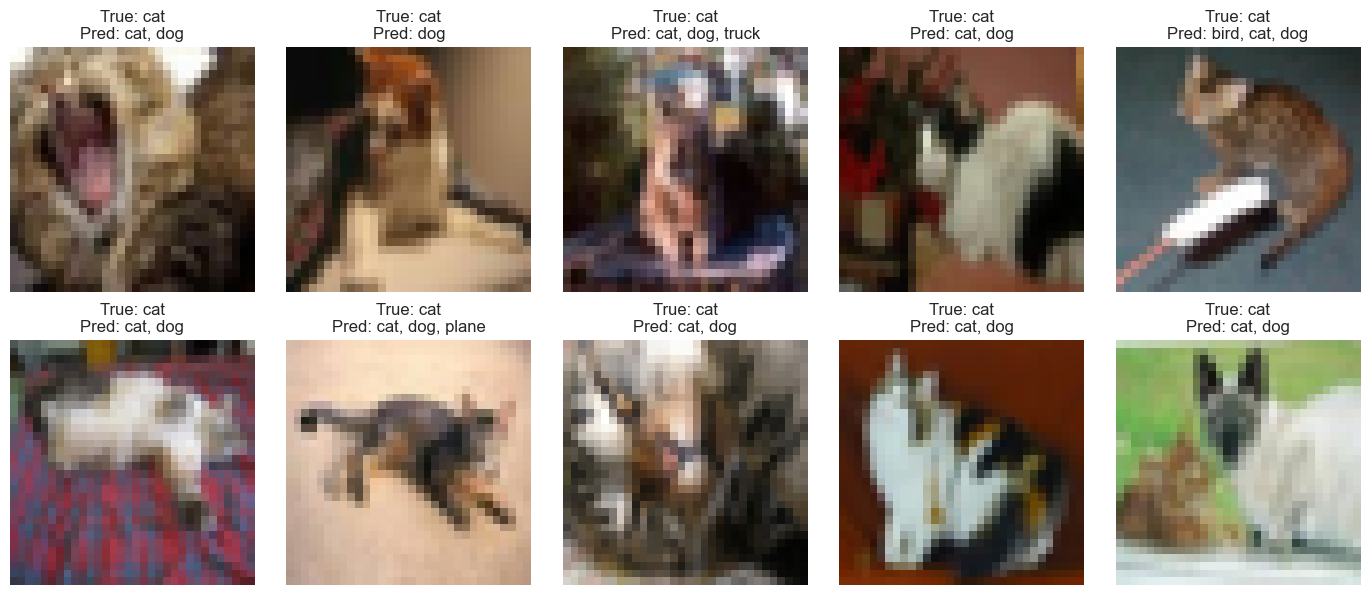

In [85]:
plot_errors(get_error_indices(true="cat", pred="dog"), n_samples=10)

Всего 413 изображений, где класс 'dog' принят за 'cat'


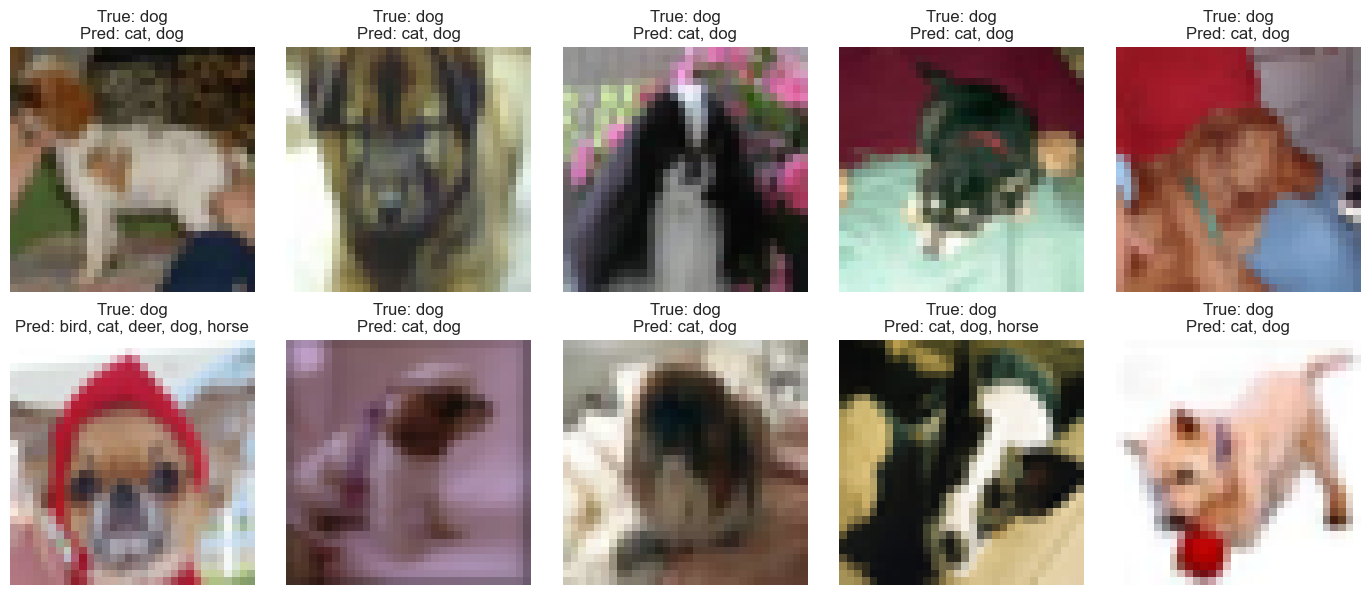

In [86]:
plot_errors(get_error_indices(true="dog", pred="cat"), n_samples=10)

Всего 118 изображений, где класс 'frog' принят за 'bird'


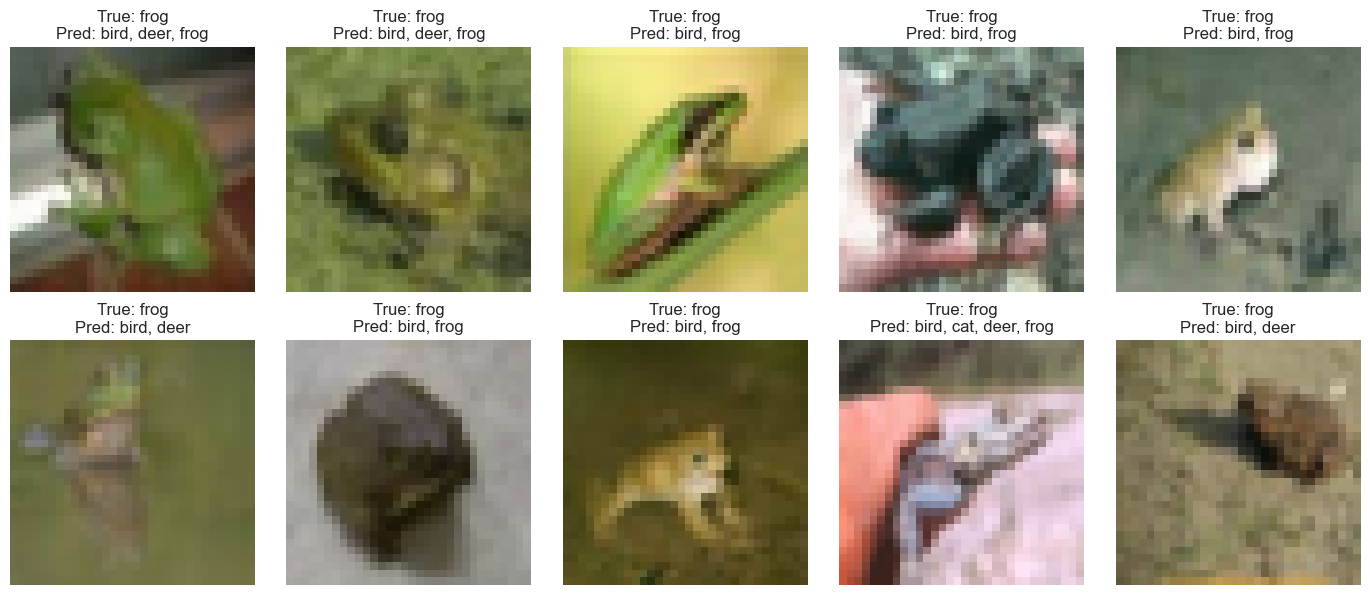

In [87]:
plot_errors(get_error_indices(true="frog", pred="bird"), n_samples=10)

Всего 197 изображений, где класс 'bird' принят за 'deer'


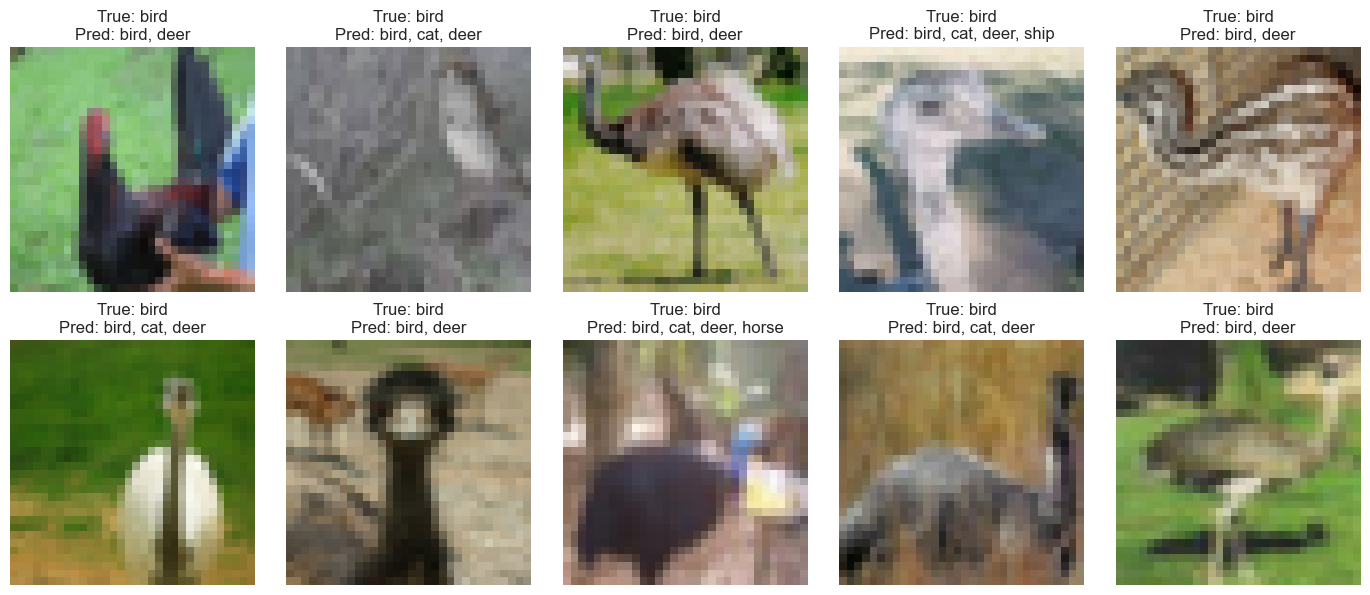

In [88]:
plot_errors(get_error_indices(true="bird", pred="deer"), n_samples=10)

Всего 113 изображений, где класс 'deer' принят за 'frog'


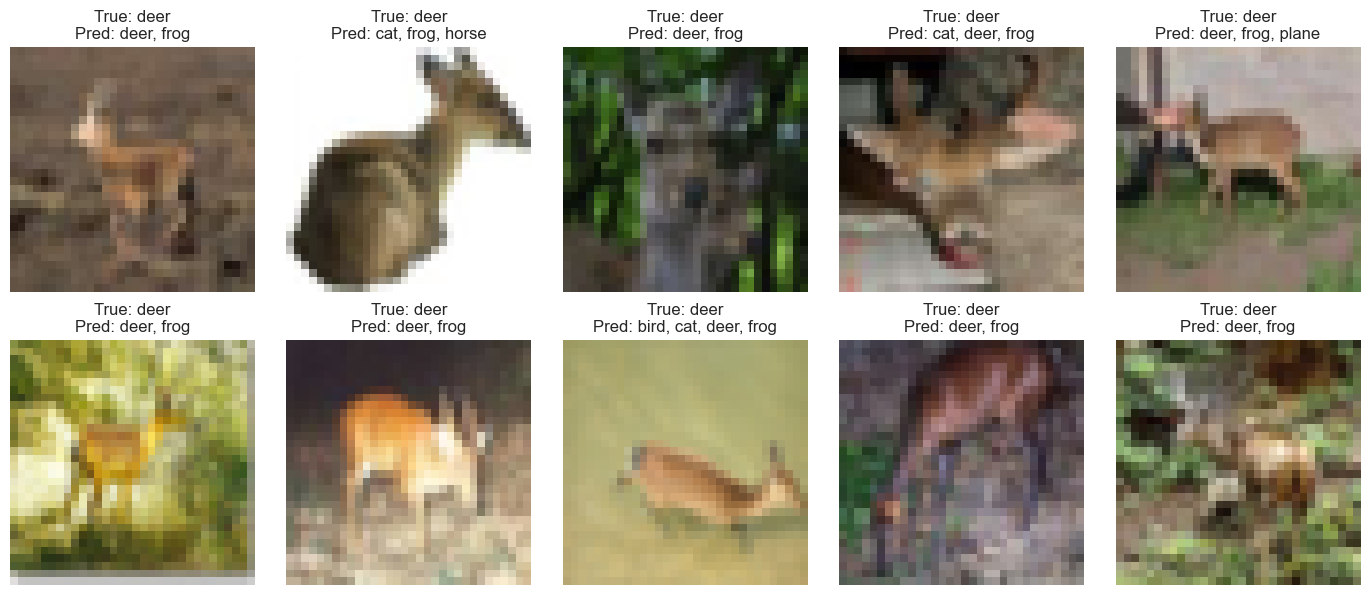

In [89]:
plot_errors(get_error_indices(true="deer", pred="frog"), n_samples=10)

Всего 159 изображений, где класс 'horse' принят за 'deer'


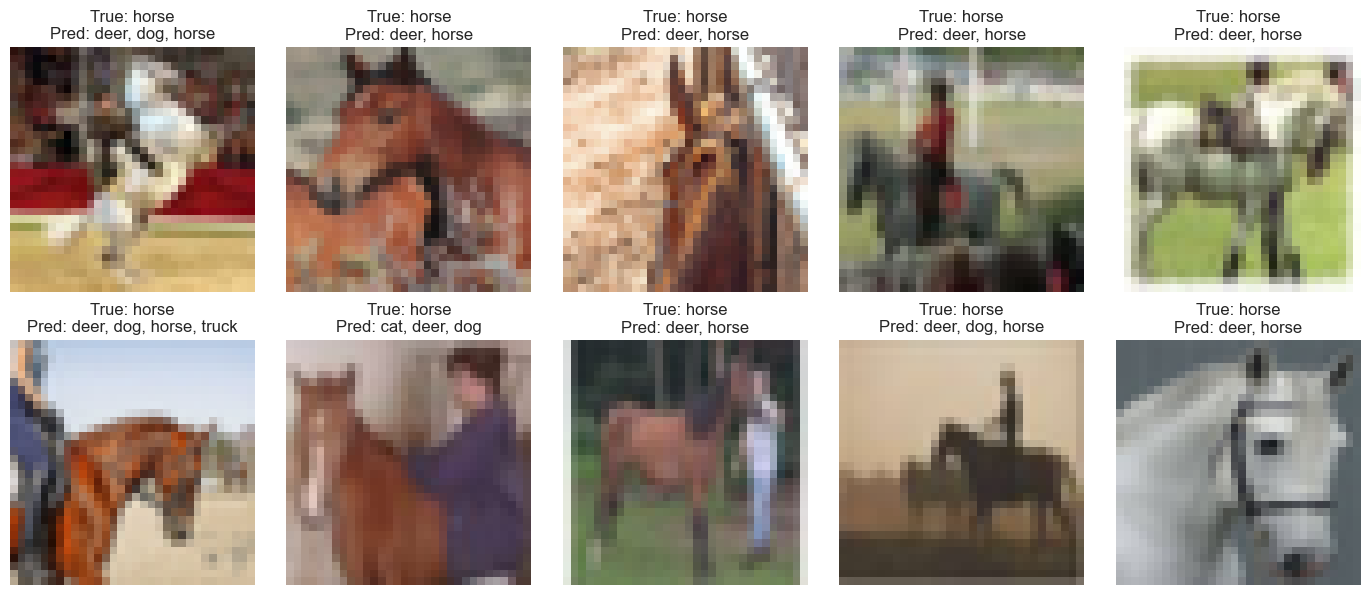

In [90]:
plot_errors(get_error_indices(true="horse", pred="deer"), n_samples=10)